In [54]:
import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import file_paths
import helper_functions

import eelbrain
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

In [55]:
# Configure the matplotlib figure style
FONT = 'Arial'
FONT_SIZE = 8
RC = {
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.transparent': True,
    # Font
    'font.family': 'sans-serif',
    'font.sans-serif': FONT,
    'font.size': FONT_SIZE,
    'figure.labelsize': FONT_SIZE,
    'figure.titlesize': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,    
    'legend.fontsize': FONT_SIZE,
}
plt.rcParams.update(RC)

In [56]:
# Load envelope decoder TRFs for all subjects
trfs = []
r_values = []

SUBJECTS = helper_functions.get_subjects()

for subject in SUBJECTS:
    attended_trf_path = file_paths.TRF_DIR / subject / f'{subject}_attended_decoder_trf.pickle'
    unattended_trf_path = file_paths.TRF_DIR / subject / f'{subject}_unattended_decoder_trf.pickle'

    if attended_trf_path.exists() and unattended_trf_path.exists():
        trf_attended = eelbrain.load.unpickle(attended_trf_path)
        trf_unattended = eelbrain.load.unpickle(unattended_trf_path)
        trfs.append((trf_attended, trf_unattended))
        
        r_values.append((trf_attended.r, trf_unattended.r))
        # Note that r does not take into account the model’s ability to predict the magnitude of the response, only its shape; for a measure that reflects both, consider using proportion_explained.

        print(f"Loaded TRFs for {subject}")
    else:
        print(f"TRF files for {subject} not found, skipping.")
        

print(f"Loaded TRFs for {len(trfs)} subjects")

Loaded TRFs for S1
Loaded TRFs for S2
Loaded TRFs for S3
Loaded TRFs for S4
Loaded TRFs for S5
Loaded TRFs for S6
Loaded TRFs for S7
Loaded TRFs for S8
Loaded TRFs for S9
Loaded TRFs for S10
Loaded TRFs for S11
Loaded TRFs for S12
Loaded TRFs for S13
Loaded TRFs for S14
Loaded TRFs for S15
Loaded TRFs for S16
Loaded TRFs for S17
Loaded TRFs for S18
Loaded TRFs for 18 subjects


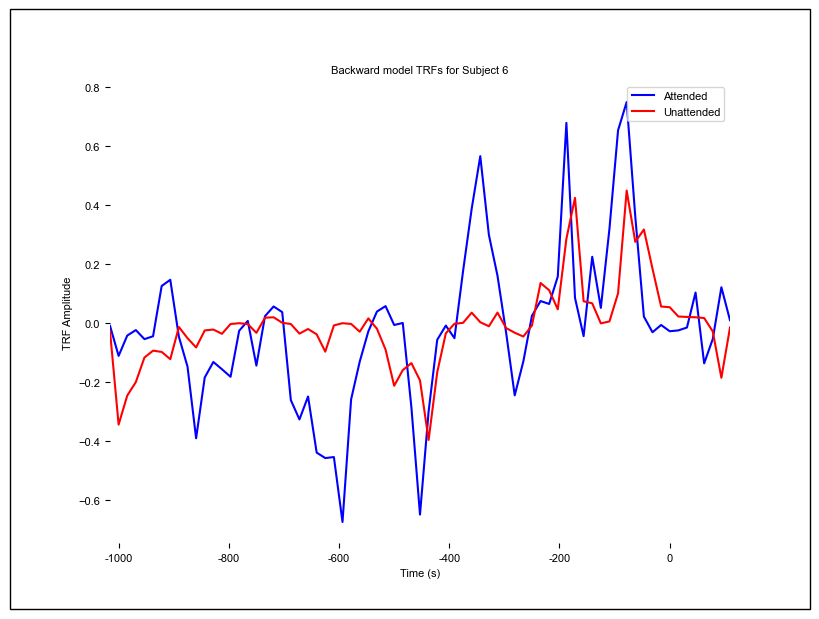

In [57]:
SUBJECT_NUMBER = 6

attended_trf_mean = trfs[SUBJECT_NUMBER -1 ][0].h_scaled.mean('sensor')
unattended_trf_mean = trfs[SUBJECT_NUMBER - 1][1].h_scaled.mean('sensor')

# plot the TRFs together in one plot for the first subject with pyplot
# Setup the figure layout
fig, axes = pyplot.subplots(1, figsize=(8, 6), sharex=True, subplot_kw=dict(frame_on=False))
eelbrain.plot.UTS(attended_trf_mean, axes=axes, color='blue')
eelbrain.plot.UTS(unattended_trf_mean, axes=axes, color='red')

# Compute sensible y-limits from the plotted curves
ymin = min(attended_trf_mean.x.min(), unattended_trf_mean.x.min())
ymax = max(attended_trf_mean.x.max(), unattended_trf_mean.x.max())
margin = 0.05 * (ymax - ymin)
axes.set_ylim(ymin - margin, ymax + margin)

axes.legend(['Attended', 'Unattended'], loc='upper right')
axes.set_title(f'Backward model TRFs for Subject {SUBJECT_NUMBER}')
axes.set_ylabel('TRF Amplitude')
axes.set_ylabel('TRF Amplitude')
axes.set_xlabel('Time (s)')


eelbrain.plot.figure_outline()
fig.savefig(file_paths.FIGURES_DIR / 'comparison_attended_unattended.png', bbox_inches='tight')

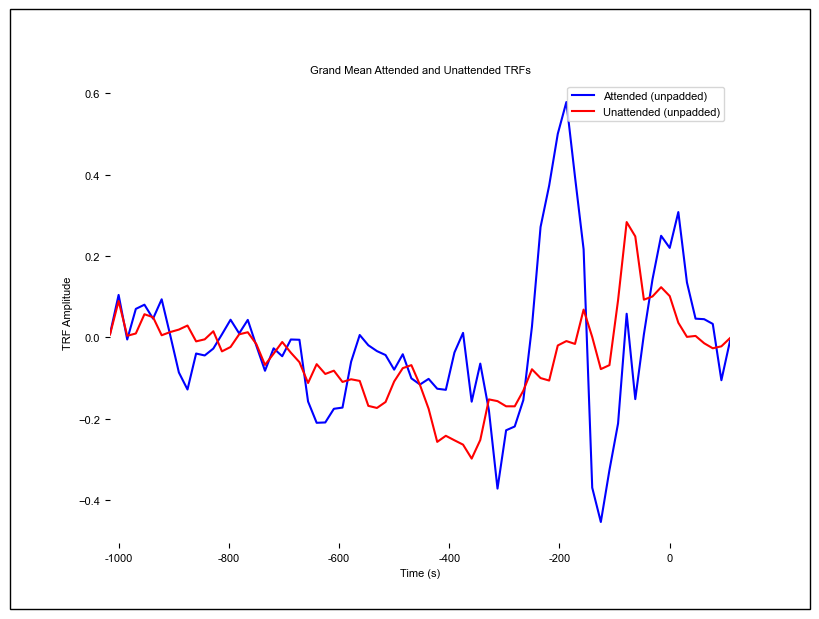

In [58]:
attended_trf_means = [trf[0].h_scaled.mean('sensor') for trf in trfs]
unattended_trf_means = [trf[1].h_scaled.mean('sensor') for trf in trfs]

# Compute grand mean TRFs across all subjects for attended and unattended (unpadded)
grand_attended_mean = eelbrain.combine(attended_trf_means).mean('case')
grand_unattended_mean = eelbrain.combine(unattended_trf_means).mean('case')

# Plot the grand mean TRFs overlaid in one plot
fig, ax = plt.subplots(1, figsize=(8, 6), subplot_kw=dict(frame_on=False))

eelbrain.plot.UTS(grand_attended_mean, axes=ax, color='blue')
eelbrain.plot.UTS(grand_unattended_mean, axes=ax, color='red')

# Compute sensible y-limits from the plotted curves
ymin = min(grand_attended_mean.x.min(), grand_unattended_mean.x.min())
ymax = max(grand_attended_mean.x.max(), grand_unattended_mean.x.max())
margin = 0.05 * (ymax - ymin)
ax.set_ylim(ymin - margin, ymax + margin)

# Legend
ax.legend(['Attended (unpadded)', 'Unattended (unpadded)'], loc='upper right')

ax.set_title('Grand Mean Attended and Unattended TRFs')
ax.set_ylabel('TRF Amplitude')
ax.set_xlabel('Time (s)')

eelbrain.plot.figure_outline()
fig.savefig(file_paths.FIGURES_DIR / 'grand_mean_attended_unattended_trfs.png', bbox_inches='tight')

In [59]:
# Summary statistics across subjects
mean_attended_r_per_subject = [r_att.mean() for (r_att, _) in r_values]
mean_unattended_r_per_subject = [r_unatt.mean() for (_, r_unatt) in r_values]

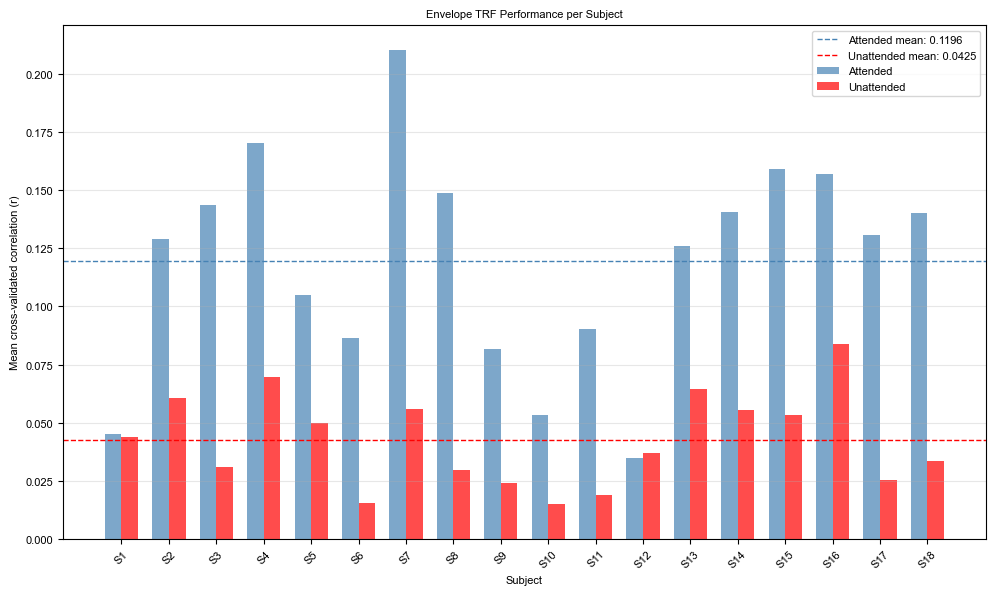

In [60]:
# Create ONE subplot
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(mean_attended_r_per_subject))
width = 0.35  # Bar width

# Attended bars
ax.bar(
    x - width/2,
    mean_attended_r_per_subject,
    width,
    color='steelblue',
    alpha=0.7,
    label='Attended'
)

# Unattended bars
ax.bar(
    x + width/2,
    mean_unattended_r_per_subject,
    width,
    color='red',
    alpha=0.7,
    label='Unattended'
)

# Grand means
ax.axhline(
    np.mean(mean_attended_r_per_subject),
    color='steelblue',
    linestyle='--',
    linewidth=1,
    label=f'Attended mean: {np.mean(mean_attended_r_per_subject):.4f}'
)

ax.axhline(
    np.mean(mean_unattended_r_per_subject),
    color='red',
    linestyle='--',
    linewidth=1,
    label=f'Unattended mean: {np.mean(mean_unattended_r_per_subject):.4f}'
)

ax.set_xlabel('Subject')
ax.set_ylabel('Mean cross-validated correlation (r)')
ax.set_title('Envelope TRF Performance per Subject')
ax.set_xticks(x)
ax.set_xticklabels(
    [f'S{i+1}' for i in range(len(mean_attended_r_per_subject))],
    rotation=45
)

ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

fig.savefig(
    file_paths.FIGURES_DIR / 'decoder_comparison_attended_unattended_summary.png',
    bbox_inches='tight'
)

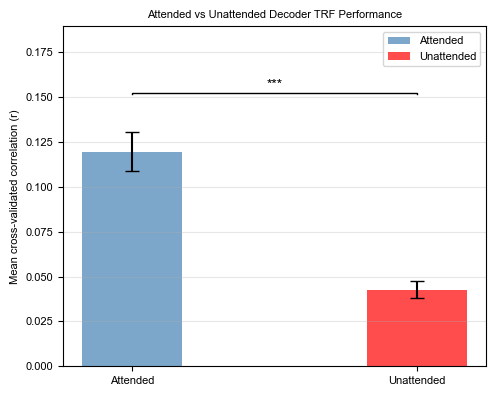

In [61]:
# show a grouped bar plot of the mean R values for each [attended, unattended] condition
# Show significance stars for the difference between padded and unpadded within each group
# and between attended and unattended within each padding condition

# Compute group means and standard errors
mean_vals = [np.mean(mean_attended_r_per_subject), np.mean(mean_unattended_r_per_subject)]

sem_vals = [np.std(mean_attended_r_per_subject, ddof=1) / np.sqrt(len(mean_attended_r_per_subject)),
            np.std(mean_unattended_r_per_subject, ddof=1) / np.sqrt(len(mean_unattended_r_per_subject))]

# Paired t-test between attended and unattended
attended_vs_unattended_t, attended_vs_unattended_p = stats.ttest_rel(mean_attended_r_per_subject, mean_unattended_r_per_subject)

def sig_marker(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

sig_attended_vs_unattended = sig_marker(attended_vs_unattended_p)

# Plot
fig, ax = plt.subplots(figsize=(5, 4))

x = np.arange(2)
width = 0.35

bars1 = ax.bar(x[0], mean_vals[0], width, yerr=sem_vals[0], capsize=5,
               color='steelblue', alpha=0.7, label='Attended')
bars2 = ax.bar(x[1], mean_vals[1], width, yerr=sem_vals[1], capsize=5,
               color='red', alpha=0.7, label='Unattended')

ax.set_xticks(x)
ax.set_xticklabels(['Attended', 'Unattended'])
ax.set_ylabel('Mean cross-validated correlation (r)')
ax.set_title('Attended vs Unattended Decoder TRF Performance')

# Add significance annotation between attended and unattended
def add_sig_line(ax, x1, x2, y, text):
    ax.plot([x1, x1, x2, x2], [y, y + 0.001, y + 0.001, y], color='k', linewidth=1)
    ax.text((x1 + x2) / 2, y + 0.002, text, ha='center', va='bottom', fontsize=10)

# Determine max y for plotting significance bars
y_max = max(mean_vals[0] + sem_vals[0], mean_vals[1] + sem_vals[1])

# Between-group annotation
y_between = max(mean_vals[0] + sem_vals[0], mean_vals[1] + sem_vals[1]) + 0.16 * y_max
add_sig_line(ax, 0, 1, y_between, sig_attended_vs_unattended)

ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, y_max * 1.45)

plt.tight_layout()
plt.show()
fig.savefig(file_paths.FIGURES_DIR / 'decoder_rbar_attended_vs_unattended.png', bbox_inches='tight')

In [64]:
# Print a LaTeX-formatted results summary using the computed mean and p-values
print("% Results summary (LaTeX)")
print()
print(r"\textbf{Mean correlation (r):} Attended (unpadded) = %.4f, Unattended (unpadded) = %.3f" % (mean_vals[0], mean_vals[1]))
print(r"\textbf{Statistical tests:}")
print(r"\begin{itemize}")
print(r"  \item Attended (unpadded) vs. Unattended (unpadded): $t(%d) = %.2f$, $p = %.3g$" % (len(mean_attended_r_per_subject)-1, attended_vs_unattended_t, attended_vs_unattended_p))
print(r"\end{itemize}")


% Results summary (LaTeX)

\textbf{Mean correlation (r):} Attended (unpadded) = 0.1196, Unattended (unpadded) = 0.043
\textbf{Statistical tests:}
\begin{itemize}
  \item Attended (unpadded) vs. Unattended (unpadded): $t(17) = 8.19$, $p = 2.64e-07$
\end{itemize}
